# Analysis of Colistin Resistance in *Acinetobacter* spp. in India (2018–2023)

## Project objective

This project analyses reported colistin resistance in *Acinetobacter* spp. bloodstream infections in India from 2018 to 2023 using antimicrobial resistance surveillance data.

The objectives are to:
- Examine yearly reported resistance percentages in India.
- Compare India's reported resistance trend with the median across reporting CTAs.
- Explore the global antibiotic resistance profile for *Acinetobacter* spp. bloodstream infections in 2023.

**Tools:** Python, Pandas, Matplotlib

**Analysis type:** Secondary data analysis

## Data and methodology

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

In [52]:
file_2023 = pd.read_csv(
    "/content/Resistance to antibiotics in 2023_All-Bloodstream.csv",
    skiprows=6,
    nrows=8
)

file_2023.head()

,Specimen,PathogenName,AntibioticName,Min,Q1,Median,Q3,Max,CTAsCount,TotalBCIsWithAST
0,Bloodstream,Acinetobacter spp.,Amikacin,0.000000,10.843373,44.206774,70.476190,94.418605,77,43102
1,Bloodstream,Acinetobacter spp.,Colistin,0.000000,0.978606,3.851852,8.263177,47.540984,46,15553
2,Bloodstream,Acinetobacter spp.,Doripenem,14.814815,33.703704,48.794643,59.007513,63.262195,4,994
3,Bloodstream,Acinetobacter spp.,Gentamicin,0.000000,27.698864,54.435288,67.289230,96.875000,83,44185
4,Bloodstream,Acinetobacter spp.,Imipenem,0.000000,31.325301,65.330189,81.818182,100.000000,73,42540


In [53]:
file_2023[["AntibioticName", "Median"]]

,AntibioticName,Median
0,Amikacin,44.206774
1,Colistin,3.851852
2,Doripenem,48.794643
3,Gentamicin,54.435288
4,Imipenem,65.330189
5,Meropenem,60.000000
6,Minocycline,7.106599
7,Tigecycline,11.872836


In [54]:
country_data = pd.read_csv(
    "/content/Time series of resistance to antibiotics (2018-2023)_All-BLOOD.csv",
    skiprows=17
)

country_data.head()

,Iso3,CountryTerritoryArea,WHORegionName,Year,Specimen,PathogenName,AbTargets,TotalSpecimenIsolates,InterpretableAST,Resistant,PercentResistant
0,ARG,Argentina,Region of the Americas,2018,BLOOD,Acinetobacter spp.,Colistin,7385,352,9,2.556818
1,BIH,Bosnia and Herzegovina,European Region,2018,BLOOD,Acinetobacter spp.,Colistin,841,63,3,4.761905
2,IND,India,South-East Asia Region,2018,BLOOD,Acinetobacter spp.,Colistin,14459,42,0,0.000000
3,IRN,Iran (Islamic Republic of),Eastern Mediterranean Region,2018,BLOOD,Acinetobacter spp.,Colistin,1826,246,20,8.130081
4,JOR,Jordan,Eastern Mediterranean Region,2018,BLOOD,Acinetobacter spp.,Colistin,345,38,4,10.526316


In [55]:
india_data = country_data[country_data["Iso3"] == "IND"]

india_data

,Iso3,CountryTerritoryArea,WHORegionName,Year,Specimen,PathogenName,AbTargets,TotalSpecimenIsolates,InterpretableAST,Resistant,PercentResistant
2,IND,India,South-East Asia Region,2018,BLOOD,Acinetobacter spp.,Colistin,14459,42,0,0.000000
13,IND,India,South-East Asia Region,2019,BLOOD,Acinetobacter spp.,Colistin,24223,330,15,4.545455
24,IND,India,South-East Asia Region,2020,BLOOD,Acinetobacter spp.,Colistin,12371,371,3,0.808625
35,IND,India,South-East Asia Region,2021,BLOOD,Acinetobacter spp.,Colistin,34056,3880,79,2.036082
46,IND,India,South-East Asia Region,2022,BLOOD,Acinetobacter spp.,Colistin,43929,4955,38,0.766902
57,IND,India,South-East Asia Region,2023,BLOOD,Acinetobacter spp.,Colistin,41375,6726,65,0.966399


In [56]:
india_data[["Year", "InterpretableAST", "Resistant", "PercentResistant"]]

,Year,InterpretableAST,Resistant,PercentResistant
2,2018,42,0,0.000000
13,2019,330,15,4.545455
24,2020,371,3,0.808625
35,2021,3880,79,2.036082
46,2022,4955,38,0.766902
57,2023,6726,65,0.966399


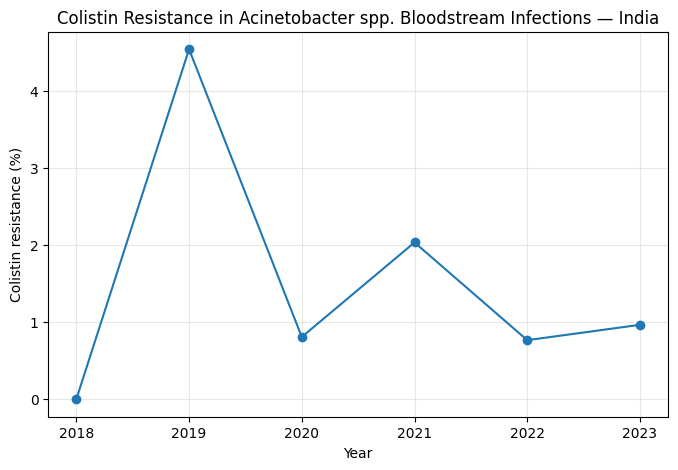

In [57]:
plt.figure(figsize=(8, 5))

plt.plot(
    india_data["Year"],
    india_data["PercentResistant"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Colistin resistance (%)")
plt.title("Colistin Resistance in Acinetobacter spp. Bloodstream Infections — India")

plt.xticks(india_data["Year"])
plt.grid(True, alpha=0.3)

plt.show()

In [58]:
global_ts = pd.read_csv(
    "/content/Time series of resistance to antibiotics (2018-2023)_All-BLOOD.csv",
    skiprows=7,
    nrows=6
)

global_ts[["Year", "Median", "Q1", "Q3"]]

,Year,Median,Q1,Q3
0,2018,1.270640,0.000000,4.599567
1,2019,2.210453,0.000000,7.702248
2,2020,2.665996,0.503356,7.643486
3,2021,2.303263,1.012883,6.737815
4,2022,3.244840,2.580658,8.042622
5,2023,3.863519,1.373210,9.164531


In [59]:
comparison = india_data[["Year", "PercentResistant"]].merge(
    global_ts[["Year", "Median"]],
    on="Year"
)

comparison

,Year,PercentResistant,Median
0,2018,0.000000,1.270640
1,2019,4.545455,2.210453
2,2020,0.808625,2.665996
3,2021,2.036082,2.303263
4,2022,0.766902,3.244840
5,2023,0.966399,3.863519


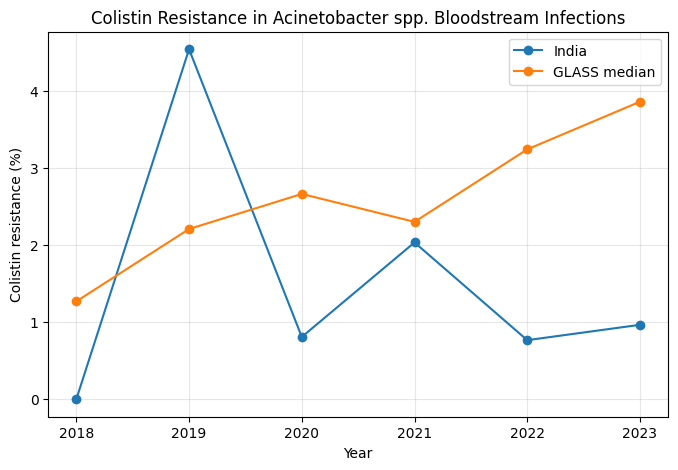

In [60]:
plt.figure(figsize=(8, 5))

plt.plot(
    comparison["Year"],
    comparison["PercentResistant"],
    marker="o",
    label="India"
)

plt.plot(
    comparison["Year"],
    comparison["Median"],
    marker="o",
    label="GLASS median"
)

plt.xlabel("Year")
plt.ylabel("Colistin resistance (%)")
plt.title("Colistin Resistance in Acinetobacter spp. Bloodstream Infections")
plt.xticks(comparison["Year"])
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [61]:
india_summary = india_data[
    ["Year", "InterpretableAST", "Resistant", "PercentResistant"]
].copy()

india_summary

,Year,InterpretableAST,Resistant,PercentResistant
2,2018,42,0,0.000000
13,2019,330,15,4.545455
24,2020,371,3,0.808625
35,2021,3880,79,2.036082
46,2022,4955,38,0.766902
57,2023,6726,65,0.966399


In [62]:
summary_2023 = file_2023[
    (file_2023["Specimen"] == "Bloodstream") &
    (file_2023["PathogenName"] == "Acinetobacter spp.")
].copy()
summary_2023

,Specimen,PathogenName,AntibioticName,Min,Q1,Median,Q3,Max,CTAsCount,TotalBCIsWithAST
0,Bloodstream,Acinetobacter spp.,Amikacin,0.000000,10.843373,44.206774,70.476190,94.418605,77,43102
1,Bloodstream,Acinetobacter spp.,Colistin,0.000000,0.978606,3.851852,8.263177,47.540984,46,15553
2,Bloodstream,Acinetobacter spp.,Doripenem,14.814815,33.703704,48.794643,59.007513,63.262195,4,994
3,Bloodstream,Acinetobacter spp.,Gentamicin,0.000000,27.698864,54.435288,67.289230,96.875000,83,44185
4,Bloodstream,Acinetobacter spp.,Imipenem,0.000000,31.325301,65.330189,81.818182,100.000000,73,42540
5,Bloodstream,Acinetobacter spp.,Meropenem,0.000000,23.138298,60.000000,76.349710,98.742138,79,43431
6,Bloodstream,Acinetobacter spp.,Minocycline,0.251731,3.416856,7.106599,21.621622,81.818182,13,12864
7,Bloodstream,Acinetobacter spp.,Tigecycline,1.058201,5.912698,11.872836,15.705128,88.764045,12,2839


In [63]:
profile_2023 = summary_2023[
    ["AntibioticName", "Median", "Q1", "Q3"]
].copy()

profile_2023

,AntibioticName,Median,Q1,Q3
0,Amikacin,44.206774,10.843373,70.476190
1,Colistin,3.851852,0.978606,8.263177
2,Doripenem,48.794643,33.703704,59.007513
3,Gentamicin,54.435288,27.698864,67.289230
4,Imipenem,65.330189,31.325301,81.818182
5,Meropenem,60.000000,23.138298,76.349710
6,Minocycline,7.106599,3.416856,21.621622
7,Tigecycline,11.872836,5.912698,15.705128


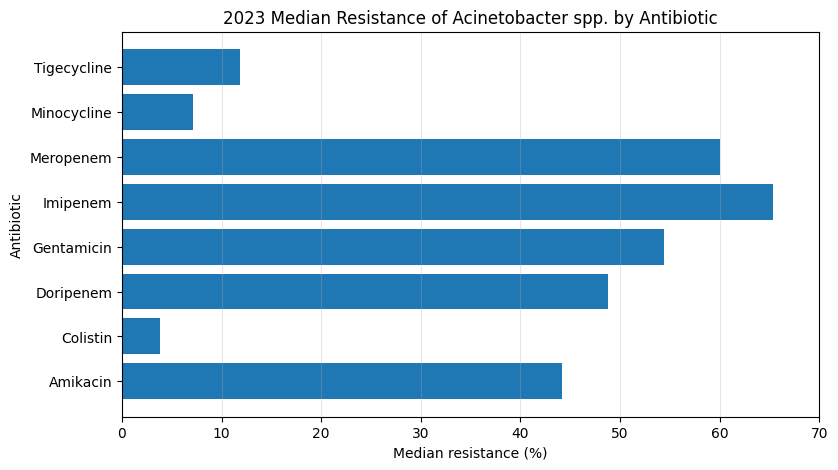

In [64]:
plot_data = profile_2023.copy()

plot_data["Median"] = pd.to_numeric(plot_data["Median"])

plt.figure(figsize=(9, 5))

plt.barh(
    plot_data["AntibioticName"],
    plot_data["Median"]
)

plt.xlabel("Median resistance (%)")
plt.ylabel("Antibiotic")
plt.title("2023 Median Resistance of Acinetobacter spp. by Antibiotic")

plt.xlim(0, 70)
plt.grid(axis="x", alpha=0.3)

plt.show()